In [1]:
from funcs import set_env
set_env()

### Data

In [21]:
from blocking import train_test_sets
import pandas as pd

data, train_pairs, test_pairs, val_pairs = train_test_sets()

print("-" * 60)
print("DATA")

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())
print("Index:")
print(data.index.name)

print("\n" + "-" * 60)
print("TRAIN PAIRS")
print("Shape:", train_pairs.shape)
print(train_pairs.columns.tolist())

print("\n" + "-" * 60)
print("TEST PAIRS")
print("Shape:", test_pairs.shape)
print(test_pairs.columns.tolist())

Loading train Candidate Pairs from file...
Loading test Candidate Pairs from file...
Loading val Candidate Pairs from file...
------------------------------------------------------------
DATA
Shape: (50000, 13)
Columns:
['record_id', 'first_name', 'last_name', 'phone', 'dob', 'city', 'state', 'postal_code', 'street_number', 'street_name', 'apt_number', 'email_user', 'email_domain']
Index:
None

------------------------------------------------------------
TRAIN PAIRS
Shape: (244622, 3)
['record_id_1', 'record_id_2', 'label']

------------------------------------------------------------
TEST PAIRS
Shape: (4136, 3)
['record_id_1', 'record_id_2', 'label']


### Overlapp

Here I will note that the model, on the first run, was a near-perfect model after just one epoch in the first train run

``` terminal
Epoch 1 Summary
--------------------------------------------------------------------------------
Train Loss : 0.034385
Test Loss  : 0.001027
Accuracy   : 0.9996
Precision  : 0.9857
Recall     : 1.0000
F1         : 0.9928
ROC-AUC    : 1.0000
PR-AUC     : 1.0000
```

Which was suspicious, least to say. Data was leaking to the model somehow, so I did many tests and founf the issue running the below snippet
``` python
train_records = set(train_pairs["record_id_1"]) | set(train_pairs["record_id_2"])
test_records  = set(test_pairs["record_id_1"]) | set(test_pairs["record_id_2"])

overlap = train_records & test_records

print("Train records:", len(train_records))
print("Test records:", len(test_records))
print("Overlap:", len(overlap))
print("Overlap %:", 100*len(overlap) / len(test_records))
```
This returned an **Overlap %: 93.354**, no wonder the model was so good, it was predicting ondata it had already seen. The issue laid in the data being split into train and test is done after the `pair_candidates` generation which lead to duplicates. The 93.354% was primarily telling us that the CNN can distinguish candidate pairs in a setting where it has already seen almost all of the records involved. So I changed the pair generation to the following

``` text
From: Raw records --> Blocking --> Pair-disjoint : train-test
To: Raw records --> Cluster-disjoint : train-test --> Blocking


In [15]:
train_records = set(train_pairs["record_id_1"]) | set(train_pairs["record_id_2"])
test_records  = set(test_pairs["record_id_1"]) | set(test_pairs["record_id_2"])
val_records  = set(val_pairs["record_id_1"]) | set(val_pairs["record_id_2"])

overlap = train_records & test_records

print("Train records:", len(train_records))
print("Test records:", len(test_records))
print("Overlap:", len(overlap))
print("Overlap %:", 100*len(overlap) / len(test_records))

Train records: 34251
Test records: 3101
Overlap: 0
Overlap %: 0.0


In [4]:
# Double check if label is working
from etl import get_data

_, cluster_data = get_data()
positive_pairs = train_pairs[train_pairs["label"] == 1]

print("Label=1")
print(positive_pairs.head(5))

for _, row in positive_pairs.head(5).iterrows():
    r1 = row["record_id_1"]
    r2 = row["record_id_2"]
    c1 = cluster_data.loc[cluster_data["record_id"] == r1, "cluster_id"].iloc[0]
    c2 = cluster_data.loc[cluster_data["record_id"] == r2, "cluster_id"].iloc[0]
    print(r1, r2, "→", c1, c2)
    
negative_pairs = train_pairs[train_pairs["label"] == 0]

print("\nLabel=0")
print(negative_pairs.head(5))

for _, row in negative_pairs.head(5).iterrows():
    r1 = row["record_id_1"]
    r2 = row["record_id_2"]
    c1 = cluster_data.loc[cluster_data["record_id"] == r1, "cluster_id"].iloc[0]
    c2 = cluster_data.loc[cluster_data["record_id"] == r2, "cluster_id"].iloc[0]
    print(r1, r2, "→", c1, c2)

Label=1
    record_id_1       record_id_2  label
4      rec_3796  rec_3796_dup3796      1
131    rec_6561  rec_6561_dup6561      1
138    rec_7550  rec_7550_dup7550      1
201    rec_3314  rec_3314_dup3314      1
220     rec_399    rec_399_dup399      1
rec_3796 rec_3796_dup3796 → clu_3796 clu_3796
rec_6561 rec_6561_dup6561 → clu_6561 clu_6561
rec_7550 rec_7550_dup7550 → clu_7550 clu_7550
rec_3314 rec_3314_dup3314 → clu_3314 clu_3314
rec_399 rec_399_dup399 → clu_399 clu_399

Label=0
  record_id_1       record_id_2  label
0   rec_18720         rec_28109      0
1   rec_33251         rec_34129      0
2   rec_39011  rec_7759_dup7759      0
3    rec_4467          rec_9318      0
5   rec_13142         rec_21409      0
rec_18720 rec_28109 → clu_18720 clu_28109
rec_33251 rec_34129 → clu_33251 clu_34129
rec_39011 rec_7759_dup7759 → clu_39011 clu_7759
rec_4467 rec_9318 → clu_4467 clu_9318
rec_13142 rec_21409 → clu_13142 clu_21409


In [ ]:
# ============================================================
# 1. RECORD + CLUSTER DISJOINTNESS
# ============================================================

# ---- Record IDs ----

print("=" * 70)
print("RECORD OVERLAP")
print("=" * 70)


train_val = train_records & val_records
train_test = train_records & test_records
val_test = val_records & test_records

print(f"Train records: {len(train_records):,}")
print(f"Val records  : {len(val_records):,}")
print(f"Test records : {len(test_records):,}")

print(f"\nTrain ∩ Val : {len(train_val):,}")
print(f"Train ∩ Test: {len(train_test):,}")
print(f"Val ∩ Test  : {len(val_test):,}")

assert len(train_val) == 0
assert len(train_test) == 0
assert len(val_test) == 0

print("\n✓ RECORDS ARE COMPLETELY DISJOINT")


# ---- Cluster IDs ----
cl = cluster_data.copy().set_index('record_id', drop=True)
train_clusters = set(cl.join(pd.DataFrame(train_records, columns=['record_id']).set_index('record_id'), how='right')['cluster_id'])
val_clusters   = set(cl.join(pd.DataFrame(val_records, columns=['record_id']).set_index('record_id'), how='right')['cluster_id'])
test_clusters  = set(cl.join(pd.DataFrame(test_records, columns=['record_id']).set_index('record_id'), how='right')['cluster_id'])

print("\n" + "=" * 70)
print("CLUSTER OVERLAP")
print("=" * 70)

train_val_clusters = train_clusters & val_clusters
train_test_clusters = train_clusters & test_clusters
val_test_clusters = val_clusters & test_clusters

print(f"Train clusters: {len(train_clusters):,}")
print(f"Val clusters  : {len(val_clusters):,}")
print(f"Test clusters : {len(test_clusters):,}")

print(f"\nTrain ∩ Val : {len(train_val_clusters):,}")
print(f"Train ∩ Test: {len(train_test_clusters):,}")
print(f"Val ∩ Test  : {len(val_test_clusters):,}")

assert len(train_val_clusters) == 0
assert len(train_test_clusters) == 0
assert len(val_test_clusters) == 0

print("\n✓ CLUSTERS ARE COMPLETELY DISJOINT")

RECORD OVERLAP
Train records: 34,251
Val records  : 3,131
Test records : 3,101

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✓ RECORDS ARE COMPLETELY DISJOINT

CLUSTER OVERLAP
Train clusters: 26,238
Val clusters  : 2,122
Test clusters : 2,123

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✓ CLUSTERS ARE COMPLETELY DISJOINT


In [56]:
# ============================================================
# 3. FIELD-LEVEL SIMILARITY DIAGNOSTICS
# ============================================================
fields = [
    "first_name",
    "last_name",
    "phone",
    "dob",
    "city",
    "state",
    "postal_code",
    "street_number",
    "street_name",
    "apt_number",
    "email_user",
    "email_domain"
]


def pair_diagnostics(data, pairs, fields):
    data_idx = data.set_index("record_id")

    a = data_idx.loc[pairs["record_id_1"]]
    b = data_idx.loc[pairs["record_id_2"]]

    diagnostics = pairs[["record_id_1","record_id_2","label"]].copy()

    for field in fields:
        diagnostics[f"{field}_same"] = (a[field].astype(str).values == b[field].astype(str).values)

    same_cols = [f"{field}_same" for field in fields]
    diagnostics["num_exact_matches"] = (diagnostics[same_cols].sum(axis=1))

    return diagnostics

train_dataset = data.join(pd.DataFrame(train_records, columns=['record_id']).set_index('record_id'), how='left')
train_diag = pair_diagnostics(train_dataset, train_pairs, fields)

val_dataset = data.join(pd.DataFrame(val_records, columns=['record_id']).set_index('record_id'), how='left')
val_diag = pair_diagnostics(val_dataset, val_pairs, fields)

test_dataset = data.join(pd.DataFrame(test_records, columns=['record_id']).set_index('record_id'), how='left')
test_diag = pair_diagnostics(test_dataset, test_pairs, fields)

# ---- Summary by label ----

for name, diag in [
    ("TRAIN", train_diag),
    ("VALIDATION", val_diag),
    ("TEST", test_diag)
]:

    print("\n" + "=" * 70)
    print(f"{name} — EXACT FIELD MATCHES")
    print("=" * 70)

    print(
        diag.groupby("label")["num_exact_matches"]
        .describe()
        .round(3)
    )
    


TRAIN — EXACT FIELD MATCHES
          count    mean    std  min   25%   50%   75%   max
label                                                      
0      236609.0   0.507  0.727  0.0   0.0   0.0   1.0   5.0
1        8013.0  10.696  1.277  6.0  10.0  11.0  11.0  12.0

VALIDATION — EXACT FIELD MATCHES
        count    mean    std  min   25%   50%   75%   max
label                                                    
0      4037.0   0.462  0.699  0.0   0.0   0.0   1.0   4.0
1      1009.0  10.756  1.242  6.0  10.0  11.0  11.0  12.0

TEST — EXACT FIELD MATCHES
        count    mean    std  min   25%   50%   75%   max
label                                                    
0      3158.0   0.569  0.761  0.0   0.0   0.0   1.0   4.0
1       978.0  10.777  1.159  6.0  10.0  11.0  11.0  12.0


In [ ]:
from sklearn.metrics import classification_report, f1_score


for name, diag in [
    ("TRAIN", train_diag),
    ("VALIDATION", val_diag),
    ("TEST", test_diag)
]:

    print("\n" + "=" * 70)
    print(f"{name} — EXACT FIELD COUNT BASELINE")
    print("=" * 70)

    for threshold in [1, 2, 3, 4, 5, 6, 8, 10]:

        predictions = (
            diag["num_exact_matches"] >= threshold
        ).astype(int)

        labels = diag["label"].values

        f1 = f1_score(
            labels,
            predictions,
            zero_division=0
        )

        print(
            f"Threshold >= {threshold:2d} | "
            f"F1 = {f1:.4f}"
        )


TRAIN — EXACT FIELD COUNT BASELINE
Threshold >=  1 | F1 = 0.1490
Threshold >=  2 | F1 = 0.3963
Threshold >=  3 | F1 = 0.8140
Threshold >=  4 | F1 = 0.9783
Threshold >=  5 | F1 = 0.9987
Threshold >=  6 | F1 = 1.0000
Threshold >=  8 | F1 = 0.9717
Threshold >= 10 | F1 = 0.9715

VALIDATION — EXACT FIELD COUNT BASELINE
Threshold >=  1 | F1 = 0.5817
Threshold >=  2 | F1 = 0.8526
Threshold >=  3 | F1 = 0.9730
Threshold >=  4 | F1 = 0.9961
Threshold >=  5 | F1 = 1.0000
Threshold >=  6 | F1 = 1.0000
Threshold >=  8 | F1 = 0.9746
Threshold >= 10 | F1 = 0.9746

TEST — EXACT FIELD COUNT BASELINE
Threshold >=  1 | F1 = 0.5927
Threshold >=  2 | F1 = 0.8352
Threshold >=  3 | F1 = 0.9683
Threshold >=  4 | F1 = 0.9980
Threshold >=  5 | F1 = 1.0000
Threshold >=  6 | F1 = 1.0000
Threshold >=  8 | F1 = 0.9797
Threshold >= 10 | F1 = 0.9797


### Error

Initial evaluation revealed that the candidate pairs generated from the original dataset were highly separable using exact field agreement. Genuine matches shared between 6 and 12 of 12 fields exactly, whereas non-matches shared at most 5 fields. Consequently, an exact-field baseline achieved near-perfect performance, limiting the ability of the neural matcher to demonstrate an advantage.

In [5]:
# Positive/negative labels in the data
values = train_pairs.groupby('label')['label'].value_counts()
print(f"Positive ratio: {values[1]/len(train_pairs['label'])}")

Positive ratio: 0.032756661297839114


In [6]:
for field in data.columns:
    print(f"{field}: {data[field].str.len().max()}")

record_id: 18
first_name: 11
last_name: 20
phone: 10
dob: 8
city: 23
state: 2
postal_code: 5
street_number: 5
street_name: 26
apt_number: 3
email_user: 25
email_domain: 22


### Test the character vocabulary

In [7]:
import string

PAD_IDX = 0
UNK_IDX = 1
chars = string.ascii_lowercase + string.digits + " .,/-'"
char_to_idx = { char: idx + 2 for idx, char in enumerate(chars) }
vocab_size = len(char_to_idx) + 2

print("Vocabulary size:", vocab_size)

for char, idx in list(char_to_idx.items())[:30]:
    print(repr(char), "→", idx)

print("PAD:", PAD_IDX)
print("UNK:", UNK_IDX)



Vocabulary size: 44
'a' → 2
'b' → 3
'c' → 4
'd' → 5
'e' → 6
'f' → 7
'g' → 8
'h' → 9
'i' → 10
'j' → 11
'k' → 12
'l' → 13
'm' → 14
'n' → 15
'o' → 16
'p' → 17
'q' → 18
'r' → 19
's' → 20
't' → 21
'u' → 22
'v' → 23
'w' → 24
'x' → 25
'y' → 26
'z' → 27
'0' → 28
'1' → 29
'2' → 30
'3' → 31
PAD: 0
UNK: 1


### Tokenization

In [8]:
import torch

def char_tokenizer(text, max_len=26):
      text = str(text).lower()
      tokens = []
      for char in text:
            tokens.append(char_to_idx.get(char, UNK_IDX))
      tokens = tokens[:max_len] # truncate
      tokens += [PAD_IDX] * (max_len - len(tokens)) # padding

      return torch.tensor(tokens, dtype=torch.long)

example_text = str(data.iloc[0]["first_name"])
print("Original:")
print(example_text)
tokens = char_tokenizer(example_text, max_len=50)
print("\nToken IDs:")
print(tokens)
print("\nShape:")
print(tokens.shape)

Original:
danielle

Token IDs:
tensor([ 5,  2, 15, 10,  6, 13, 13,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

Shape:
torch.Size([50])


### Datasets

In [9]:
from feature_extractor import data

train_dataset, test_dataset, val_dataset, train_loader, test_loader, val_loader = data()

features_A, features_B, label = train_dataset[0]

print("Label:", label)

fields = features_A.keys()
print("\nFields:", fields)

for field in fields:

    print(f"\n--- {field} ---")

    print("A:")
    print(features_A[field])
    print("Shape:", features_A[field].shape)

    print("B:")
    print(features_B[field])
    print("Shape:", features_B[field].shape)

Loading train Candidate Pairs from file...
Loading test Candidate Pairs from file...
Loading val Candidate Pairs from file...
Label: tensor(0.)

Fields: dict_keys(['first_name', 'last_name', 'phone', 'dob', 'city', 'state', 'postal_code', 'street_number', 'street_name', 'apt_number', 'email_user', 'email_domain'])

--- first_name ---
A:
tensor([15,  2, 21,  9,  2, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])
Shape: torch.Size([23])
B:
tensor([11, 16,  9, 15,  2, 21,  9,  2, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])
Shape: torch.Size([23])

--- last_name ---
A:
tensor([23,  2, 27, 18, 22,  6, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])
Shape: torch.Size([23])
B:
tensor([23,  2, 13,  5,  6, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])
Shape: torch.Size([23])

--- phone ---
A:
tensor([36, 28, 36, 34, 30, 33, 28, 33, 29, 32,  0,  0,  0,  0,  0,  0,  0,  0,
   

### See the pairs

In [15]:
def show_pair(dataset, idx, fields):

    row = dataset.pairs.iloc[idx]

    record_A = dataset.data.loc[row["record_id_1"]]
    record_B = dataset.data.loc[row["record_id_2"]]

    print("=" * 70)
    print(f"PAIR {idx}")
    print("=" * 70)

    print("Record A:", row["record_id_1"])
    print("Record B:", row["record_id_2"])
    print("LABEL:", row["label"])

    for field in fields:

        print(f"\n[{field}]")

        print("A:", record_A[field])
        print("B:", record_B[field])

positive_idx = train_pairs.index[train_pairs["label"] == 1][0]
negative_idx = train_pairs.index[train_pairs["label"] == 0][0]

       
show_pair(train_dataset, positive_idx, fields)
show_pair(train_dataset, negative_idx, fields)

PAIR 4
Record A: rec_21045
Record B: rec_7509
LABEL: 0

[first_name]
A: justin
B: dustin

[last_name]
A: kelley
B: anderson

[phone]
A: 5054573990
B: 6015622809

[dob]
A: 19700603
B: 19570308

[city]
A: charlesberg
B: northjenniferborough

[state]
A: nm
B: ms

[postal_code]
A: 87992
B: 38968

[street_number]
A: 04749
B: 07710

[street_name]
A: andersonfall
B: jessicarun

[apt_number]
A: 000
B: 000

[email_user]
A: justinkelley
B: anderson_dustin

[email_domain]
A: gmail
B: andersen-mcdonald
PAIR 0
Record A: rec_38920
Record B: rec_6453
LABEL: 0

[first_name]
A: nathan
B: johnathan

[last_name]
A: vazquez
B: valdez

[phone]
A: 8086250514
B: 3037872441

[dob]
A: 19700428
B: 20011116

[city]
A: newsheri
B: lakebillyfurt

[state]
A: hi
B: co

[postal_code]
A: 96719
B: 81211

[street_number]
A: 00164
B: 00370

[street_name]
A: maciascenters
B: adambranch

[apt_number]
A: 000
B: 000

[email_user]
A: nathan_vazquez
B: johnathanv

[email_domain]
A: aol
B: outlook


### Test loader

In [16]:
batch_A, batch_B, labels = next(iter(train_loader))

print("Labels:")
print(labels)

print("\nBatch shapes:")

for field in fields:

    print(
        field,
        "A:", batch_A[field].shape,
        "B:", batch_B[field].shape
    )

Labels:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])

Batch shapes:
first_name A: torch.Size([128, 23]) B: torch.Size([128, 23])
last_name A: torch.Size([128, 23]) B: torch.Size([128, 23])
phone A: torch.Size([128, 23]) B: torch.Size([128, 23])
dob A: torch.Size([128, 23]) B: torch.Size([128, 23])
city A: torch.Size([128, 23]) B: torch.Size([128, 23])
state A: torch.Size([128, 23]) B: torch.Size([128, 23])
postal_code A: torch.Size([128, 23]) B: torch.Size([128, 2

In [17]:
from feature_extractor import CharCNN
from funcs import get_device

device = get_device()
cnn = CharCNN().to(device)
name_batch = batch_A["first_name"].to(device)

embedding = cnn(name_batch)

print("Input:")
print(name_batch.shape)

print("\nEmbedding:")
print(embedding.shape)

Input:
torch.Size([128, 23])

Embedding:
torch.Size([128, 128])


### Complete EntityMatcher

In [18]:
from feature_extractor import EntityMatcher

model = EntityMatcher(
    vocab_size=vocab_size,
    fields=fields,
    embedding_dim=128
).to(device)

In [19]:
batch_A, batch_B, labels = next(iter(train_loader))
batch_A = {field: batch_A[field].to(device) for field in fields}
batch_B = {field: batch_B[field].to(device) for field in fields}

labels = labels.to(device)

with torch.no_grad():
    logits, embeddings_A, embeddings_B = model(
        batch_A,
        batch_B,
        return_embeddings=True
    )

print("Logits:")
print(logits)

print("\nLogits shape:")
print(logits.shape)

Logits:
tensor([0.2133, 0.2216, 0.1893, 0.0068, 0.2938, 0.2864, 0.4655, 0.4973, 0.5216,
        0.2037, 0.3704, 0.4946, 0.1873, 0.1503, 0.3427, 0.1189, 0.4395, 0.1341,
        0.3656, 0.2591, 0.4812, 0.2428, 0.1434, 0.2991, 0.3427, 0.4298, 0.3636,
        0.2334, 0.1698, 0.3177, 0.1417, 0.1499, 0.4756, 0.2893, 0.3030, 0.5708,
        0.2173, 0.2002, 0.2064, 0.1760, 0.1777, 0.1622, 0.3415, 0.2557, 0.3114,
        0.1923, 0.2502, 0.2473, 0.2981, 0.1870, 0.1045, 0.2473, 0.3975, 0.2285,
        0.1798, 0.4215, 0.3554, 0.3112, 0.1927, 0.2105, 0.1787, 0.2204, 0.2940,
        0.4563, 0.1794, 0.2689, 0.3135, 0.2194, 0.6791, 0.2037, 0.1896, 0.1267,
        0.2560, 0.4139, 0.3187, 0.2122, 0.3256, 0.2004, 0.3912, 0.1117, 0.3865,
        0.0522, 0.2485, 0.1528, 0.5689, 0.4440, 0.3030, 0.2460, 0.1401, 0.3773,
        0.0767, 0.3464, 0.3876, 0.3465, 0.3956, 0.4962, 0.2494, 0.3209, 0.5660,
        0.1250, 0.2333, 0.1404, 0.3964, 0.2193, 0.3587, 0.3003, 0.3461, 0.1307,
        0.2156, 0.4682, 0.4309, 

### Embeddings

In [20]:
for field in fields:
    print(f"{field:15s}", "A:", tuple(embeddings_A[field].shape),
        "B:", tuple(embeddings_B[field].shape)
    )

first_name      A: (128, 128) B: (128, 128)
last_name       A: (128, 128) B: (128, 128)
phone           A: (128, 128) B: (128, 128)
dob             A: (128, 128) B: (128, 128)
city            A: (128, 128) B: (128, 128)
state           A: (128, 128) B: (128, 128)
postal_code     A: (128, 128) B: (128, 128)
street_number   A: (128, 128) B: (128, 128)
street_name     A: (128, 128) B: (128, 128)
apt_number      A: (128, 128) B: (128, 128)
email_user      A: (128, 128) B: (128, 128)
email_domain    A: (128, 128) B: (128, 128)


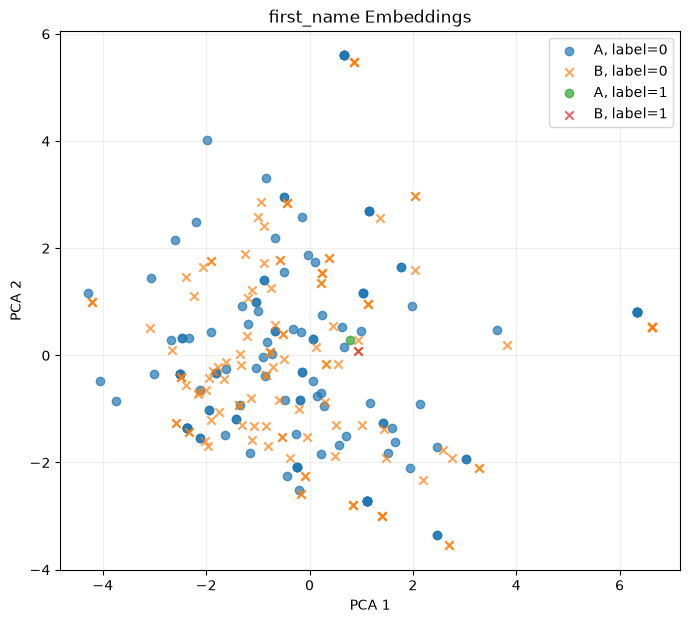

In [21]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def visualize_field_embeddings( embeddings_A, embeddings_B, labels, field):

    A = embeddings_A[field].detach().cpu().numpy()
    B = embeddings_B[field].detach().cpu().numpy()

    labels = labels.cpu().numpy()
    all_embeddings = np.vstack([A, B])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_embeddings)
    n = len(A)

    A_coords = coords[:n]
    B_coords = coords[n:]

    plt.figure(figsize=(8, 7))

    for label in [0, 1]:
        mask = labels == label
        plt.scatter(
            A_coords[mask, 0],
            A_coords[mask, 1],
            label=f"A, label={label}",
            alpha=0.7
        )

        plt.scatter(
            B_coords[mask, 0],
            B_coords[mask, 1],
            marker="x",
            label=f"B, label={label}",
            alpha=0.7
        )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"{field} Embeddings")

    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

visualize_field_embeddings(embeddings_A, embeddings_B, labels, field="first_name")

### Field Similarity

In [20]:
import torch.nn.functional as F

def field_similarities(embeddings_A, embeddings_B, fields):
    similarities = {}
    for field in fields:
        A = embeddings_A[field]
        B = embeddings_B[field]
        sim = F.cosine_similarity(A, B, dim=1)
        similarities[field] = sim.detach().cpu()

    return similarities

similarities = field_similarities(embeddings_A, embeddings_B, fields)
for field in fields:
    print(field, similarities[field])

first_name tensor([0.9909, 0.3115, 0.5534, 0.9934, 0.2397, 0.2742, 0.4735, 0.1930, 0.1217,
        0.2520, 0.2535, 0.3642, 0.2914, 0.5943, 0.4819, 0.4172, 0.2597, 0.3036,
        0.2506, 0.3713, 0.9940, 0.9939, 0.9894, 0.9909, 0.9910, 0.2828, 0.2082,
        0.2557, 0.9872, 0.2068, 0.9931, 0.3274, 0.3519, 0.9935, 0.2567, 0.4560,
        0.4711, 0.3528, 0.4350, 0.3657, 0.9850, 0.5883, 0.3734, 0.9931, 0.4152,
        0.4946, 0.5202, 0.2900, 0.4566, 0.5322, 0.2976, 0.5233, 0.3817, 0.4933,
        0.3539, 0.3825, 0.6716, 0.2164, 0.2649, 0.9939, 0.9893, 0.2927, 0.9915,
        0.3253, 0.4259, 0.3259, 0.9939, 0.2989, 0.1262, 0.9909, 0.4505, 0.9885,
        0.5033, 0.3161, 0.3749, 0.4662, 0.3967, 0.3158, 0.2260, 0.9909, 0.9909,
        0.9878, 0.3297, 0.9930, 0.9876, 0.2257, 0.1290, 0.9862, 0.9910, 0.2032,
        0.9937, 0.2926, 0.9923, 0.4550, 0.9851, 0.3701, 0.2166, 0.2555, 0.9938,
        0.4007, 0.3054, 0.2529, 0.1337, 0.2843, 0.2229, 0.1970, 0.2722, 0.4706,
        0.9939, 0.2955, 0.308

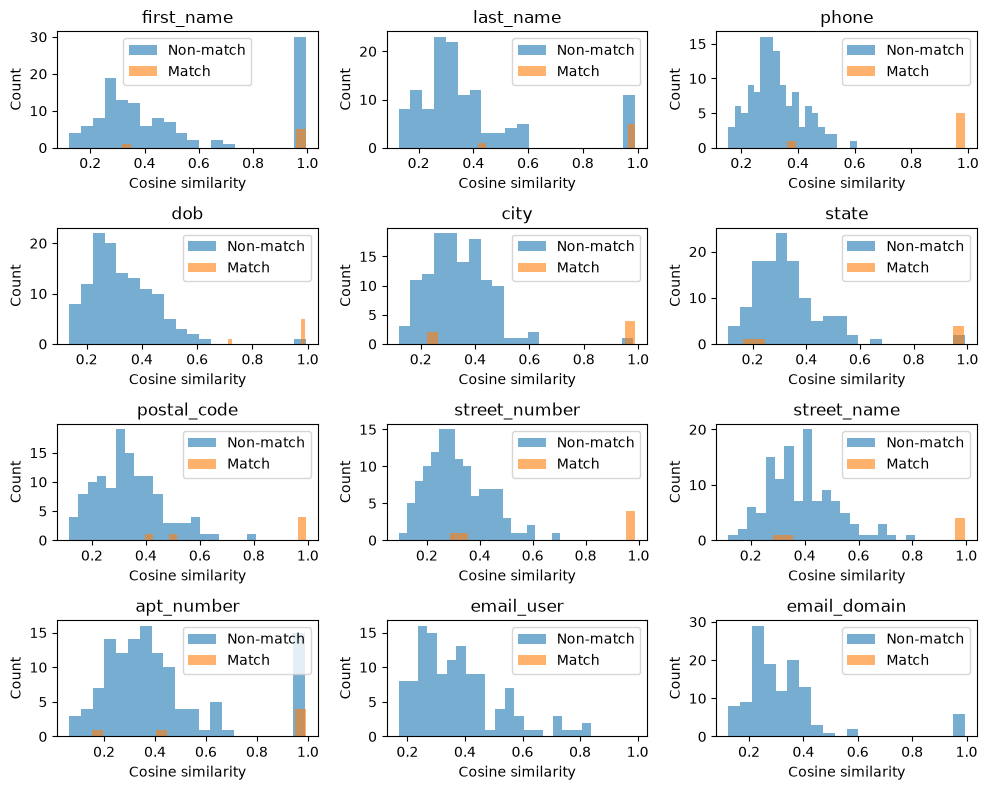

In [29]:
def plot_field_similarities(
    similarities,
    labels,
    fields
):

    labels = labels.cpu().numpy()

    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10,8))

    # Flatten the 2D array of axes to easily iterate over them in a 1D loop
    flat_axes = axes.flatten()

    for ax, field in zip(flat_axes, fields):
        values = similarities[field].numpy()
        match_values = values[labels == 1]
        nonmatch_values = values[labels == 0]
        ax.hist(nonmatch_values, bins=20, alpha=0.6, label="Non-match")
        ax.hist(match_values, bins=20, alpha=0.6, label="Match")

        ax.set_title(field)
        ax.set_xlabel("Cosine similarity")
        ax.set_ylabel("Count")

        ax.legend()

    plt.tight_layout()
    plt.show()

plot_field_similarities(similarities, labels, fields)

### Posibilities

In [30]:
probabilities = torch.sigmoid(logits)

for i in range(len(labels)):
    print(
        f"Pair {i}: "
        f"label={labels[i].item():.0f}, "
        f"probability={probabilities[i].item():.4f}"
    )

Pair 0: label=0, probability=0.5627
Pair 1: label=0, probability=0.5864
Pair 2: label=0, probability=0.5998
Pair 3: label=1, probability=0.5971
Pair 4: label=0, probability=0.5567
Pair 5: label=0, probability=0.5598
Pair 6: label=0, probability=0.5514
Pair 7: label=0, probability=0.6566
Pair 8: label=0, probability=0.5596
Pair 9: label=0, probability=0.6249
Pair 10: label=0, probability=0.4968
Pair 11: label=0, probability=0.6147
Pair 12: label=0, probability=0.5435
Pair 13: label=0, probability=0.5899
Pair 14: label=0, probability=0.5458
Pair 15: label=0, probability=0.5676
Pair 16: label=0, probability=0.5123
Pair 17: label=0, probability=0.6248
Pair 18: label=0, probability=0.5397
Pair 19: label=0, probability=0.5598
Pair 20: label=0, probability=0.6074
Pair 21: label=0, probability=0.5903
Pair 22: label=0, probability=0.5289
Pair 23: label=0, probability=0.5447
Pair 24: label=0, probability=0.5380
Pair 25: label=0, probability=0.5900
Pair 26: label=0, probability=0.5350
Pair 27: la

### **One** training step

In [31]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

model.train()

batch_A, batch_B, labels = next(iter(train_loader))
batch_A = {field: batch_A[field].to(device) for field in fields}
batch_B = {field: batch_B[field].to(device) for field in fields}
labels = labels.to(device)

optimizer.zero_grad()

logits = model(batch_A, batch_B)
loss = criterion(logits, labels)

print("Loss before backward:", loss.item())
loss.backward()
optimizer.step()
print("One optimization step completed.")


Loss before backward: 0.8313778042793274
One optimization step completed.


In [32]:
for name, parameter in model.named_parameters():
    if parameter.grad is not None:
        print(f"{name:50s}", f"mean_grad={parameter.grad.abs().mean().item():.8f}")

encoders.first_name.embedding.weight               mean_grad=0.00007411
encoders.first_name.conv3.weight                   mean_grad=0.00052853
encoders.first_name.conv3.bias                     mean_grad=0.00005358
encoders.first_name.conv5.weight                   mean_grad=0.00049691
encoders.first_name.conv5.bias                     mean_grad=0.00001873
encoders.first_name.conv7.weight                   mean_grad=0.00049011
encoders.first_name.conv7.bias                     mean_grad=0.00002241
encoders.first_name.fc.0.weight                    mean_grad=0.00038670
encoders.first_name.fc.0.bias                      mean_grad=0.00000000
encoders.first_name.fc.1.weight                    mean_grad=0.00024894
encoders.first_name.fc.1.bias                      mean_grad=0.00018476
encoders.last_name.embedding.weight                mean_grad=0.00007313
encoders.last_name.conv3.weight                    mean_grad=0.00053592
encoders.last_name.conv3.bias                      mean_grad=0.0